# PIPELINE PARALELO DE PROCESSAMENTO DE IMAGENS COM MULTIPROCESSING

INSTITUTO FEDERAL DE MINAS GERIAS Departamento de Engenharia e Computação

Alunos: Antonio Ambrosio, Euler Gomes e Vinicius Miguel


# 1. Preparação do ambiente

In [16]:
from IPython.display import display, HTML
from torch.utils.data import DataLoader

display(HTML("<style>.container {widht: 100% !important;}</style>"))

## 1.1. Importação das bibliotecas

In [17]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import time
import shutil
import subprocess
import sys
import os
import kagglehub
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torchvision.datasets import ImageFolder

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary

## 1.2. Exporta requirements (Fase 1)

In [18]:
def exporta_requirements():
    try:
        result = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                                capture_output=True,
                                text=True,
                                check=True)
        with open('requirements.txt', 'w') as f:
            f.write(result.stdout)
        print('requirements.txt gerado com sucesso.')
    except subprocess.CalledProcessError as e:
        print('erro:', e)


exporta_requirements()

requirements.txt gerado com sucesso.


## 1.3. Checagem de GPU

In [19]:
if torch.cuda.is_available():
    print("__CUDNN VERSION:", torch.backends.cudnn.version())
    print("Device:", torch.cuda.get_device_name(0))
    device = 'cuda'
else:
    print("CUDA não disponivel.")
    device = 'cpu'

print('Device:', device)

__CUDNN VERSION: 91501
Device: NVIDIA GeForce RTX 5070
Device: cuda


# 2. Carregar Dataset

## 2.1. Baixar dataset

In [20]:
baixar_dataset = False

if baixar_dataset:
    path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

    dest = Path("../parallel_loading/data/raw")
    dest.mkdir(parents=True, exist_ok=True)

    os.system(f"ln -s {path}/* {dest}")

## 2.2. Juntar dataset

In [21]:
img_data1 = "/parallel_loading/data/raw/HAM10000_images_part_1"
img_data2 = "/parallel_loading/data/raw/HAM10000_images_part_2"
dest = "data/raw/images"

os.makedirs(dest, exist_ok=True)

juntar_data = False

if juntar_data:
    for folder in [img_data1, img_data2]:
        if os.path.exists(folder):
            for file in os.listdir(folder):
                shutil.copy(os.path.join(folder, file), dest)
        else:
            print(
                f"Warning: Folder not found: {folder}. Skipping. Please ensure the dataset was downloaded and linked correctly in the previous step.")

## 2.3. Dividir dataset

In [22]:
df = pd.read_csv('data/raw/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [23]:
grouped = df.groupby('lesion_id').first().reset_index()
grouped.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000000,ISIC_0028498,nv,histo,60.0,male,back
1,HAM_0000001,ISIC_0027859,bkl,histo,70.0,female,face
2,HAM_0000002,ISIC_0033848,mel,histo,65.0,female,lower extremity
3,HAM_0000003,ISIC_0027886,nv,follow_up,55.0,male,trunk
4,HAM_0000004,ISIC_0024645,nv,follow_up,40.0,female,back


In [24]:
train_df, temp_df = train_test_split(
    grouped,
    test_size=0.3,
    stratify=grouped['dx'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['dx'],
    random_state=42
)

In [25]:
train = df[df['lesion_id'].isin(train_df['lesion_id'])]
val = df[df['lesion_id'].isin(val_df['lesion_id'])]
test = df[df['lesion_id'].isin(test_df['lesion_id'])]

In [26]:
def organize(df, split_name):
    for _, row in df.iterrows():
        label = row['dx']
        img_id = row['image_id'] + ".jpg"

        img_path = f"data/raw/images/{img_id}"
        dest_path = f"data/split/{split_name}/{label}/{img_id}"

        os.makedirs(os.path.dirname(dest_path), exist_ok=True)
        shutil.copy(img_path, dest_path)


organize(train, "train")
organize(val, "val")
organize(test, "test")

## 2.4. Exploração do dataset

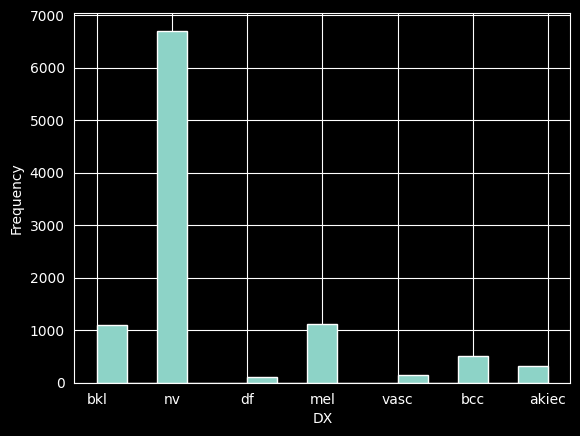

In [35]:
plt.hist(df["dx"], bins=15)
plt.xlabel("DX")
plt.ylabel("Frequency")
plt.show()

In [36]:
df.isna().sum().sort_values(ascending=False)

age             57
image_id         0
lesion_id        0
dx               0
dx_type          0
sex              0
localization     0
dtype: int64

# 3. Pré Processamento

## 3.1. Transformações

In [27]:
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [28]:
train_dataset = ImageFolder("data/split/train", transform=transform_train)
val_dataset = ImageFolder("data/split/val", transform=transform_test)
test_dataset = ImageFolder("data/split/test", transform=transform_test)

## 3.2. Data Loader (Fase 2)

In [37]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=7, input_channels=3):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        # Para entrada 128x128, após 3 pools (2^3 = 8), dimensão final = 128/8 = 16
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [34]:
learning_rate = 0.001
batch_size = 32
num_worker = 4

max_epochs = 5

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_worker)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_worker)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_worker)


model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate)
